# Crisis Windows and Framing: Hypothesis Tests

Tests the hypotheses in `Project_Proposal.md` §7 against the per-post LLM scores: does FFF
Germany's framing shift across the six crisis windows (`src/crisis_windows.py`), and does it
shift in the *direction* the framing-alignment literature predicts?

| | Hypothesis | Test below |
|---|---|---|
| **H1** | *Crowding produces extension into the matching arena.* An exogenous crisis pulls climate framing into the inequality arena connected to that crisis -- `innen_aussen` in the Ukraine window, `oben_unten` in the cost-of-living window, `wir_sie` in the Gaza window -- more than into the other windows. | Window shifts in arena presence; per arena, contrast "matched window vs. mean of the other crisis windows" |
| **H2** | *Master-frame shift toward justice.* `climate_justice` gains on `climate_change`, most in crisis windows. | Window shifts in the per-post gap `climate_justice - climate_change` |
| **H3** | *Amplification of mobilization.* Crises shift the DPM mix toward `motivational` and away from `diagnostic`; the election-driven politics window most of all. | Window shifts in `motivational` / `diagnostic` share of a post's DPM total |
| **H4** | *Participation link.* Mobilization framing peaks in the two weeks before participation events (global strikes, elections), and that peak weakens in the later period. | Pre-event indicator x period interaction on motivational share |

**Design.** One OLS model per outcome, `outcome ~ window + log(words) + account`, with
`baseline` (Dec 2018 - Feb 2020) as the reference window and HAC (Newey-West) standard errors.
The two controls are there because two things changed across the period besides framing:
captions got much longer (2019 median ~40 words, 2020 ~70) and the LLM's intensity scores rise
with caption length; and *who* posts changed (the national account fades after 2022; Hamburg and
Berlin carry the late corpus). The pre-checks below show both. Arena outcomes are modelled as
**presence** (score >= 1) rather than 0-4 intensity, because 75-85% of posts score 0 on them -- a
window shift there is a change in the share of posts that invoke the arena at all.

Within-window slopes (an earlier version of this notebook) are dropped: the hypotheses are about
levels, and a linear trend inside a two-year window was not a credible assumption. Results are
correlational -- windows are calendar periods, and every secular change in the movement loads
onto them -- so the write-up should say "in the period after X", not "because of X".

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.multitest import multipletests
from IPython.display import display

from src import plot_style
from src.crisis_windows import CRISIS_WINDOWS, resolve_windows
from src.key_events import KEY_EVENTS

plot_style.set_style()

## Data: One Row per Post, All Axes

Debiased per-post scores (mean across orderings -- a no-op for the single-ordering full runs)
joined to the Germany-only corpus (`data/processed/FFF_german.csv`), with the two controls and
the derived outcomes for H1-H3.

In [2]:
AXES = {
    "DPM":               ["diagnostic", "prognostic", "motivational"],
    "DPM Subcategories": ["blame_attribution", "problem_identification", "solutions", "tactics", "rationale", "call_to_action"],
    "Master Frame":      ["climate_change", "climate_justice"],
    "Inequality Arena":  ["oben_unten", "innen_aussen", "wir_sie", "heute_morgen"],
}
SCORE_FILES = {
    "DPM": "axis_a_dpm_de", "DPM Subcategories": "axis_b_dpm_subcategories_de",
    "Master Frame": "axis_c_masterframe_de", "Inequality Arena": "axis_d_arena_de",
}
ARENAS = AXES["Inequality Arena"]
ALL_CONCEPTS = [c for concepts in AXES.values() for c in concepts]
REFERENCE_WINDOW = "baseline"

corpus = pd.read_csv("../data/processed/FFF_german.csv", dtype={"id": str}, low_memory=False)
corpus["creation_time"] = pd.to_datetime(corpus["creation_time"], utc=True)
corpus = (corpus.set_index("id")[["creation_time", "clean_word_count", "post_owner.username"]]
          .rename(columns={"post_owner.username": "account"}))
corpus["log_words"] = np.log1p(corpus["clean_word_count"])

scores = None
for axis, concepts in AXES.items():
    raw = pd.read_csv(f"../data/llm_scores/{SCORE_FILES[axis]}.csv", dtype={"text_id": str})
    means = raw.groupby("text_id")[concepts].mean()
    scores = means if scores is None else scores.join(means, how="inner")

# inner join: Germany-based posts that carry a score on every axis (parse failures drop out)
posts = corpus.join(scores, how="inner").dropna().sort_values("creation_time")
print(f"{len(posts)} posts with scores on all four axes ({len(corpus)} in the corpus, {len(scores)} scored)")

resolved_windows = resolve_windows(CRISIS_WINDOWS, posts["creation_time"].max())
WINDOW_ORDER = [name for name, *_ in resolved_windows]
CRISIS_WINDOWS_ONLY = [w for w in WINDOW_ORDER if w != REFERENCE_WINDOW]

posts["window"] = pd.Categorical(
    posts["creation_time"].apply(lambda ts: next((n for n, s, e, _d in resolved_windows if s <= ts <= e), None)),
    categories=WINDOW_ORDER,
)
assert posts["window"].notna().all(), "a post fell outside every crisis window"

for arena in ARENAS:
    posts[f"{arena}_present"] = (posts[arena] >= 1).astype(int)
posts["justice_gap"] = posts["climate_justice"] - posts["climate_change"]
dpm_total = posts[AXES["DPM"]].sum(axis=1)
posts["motivational_share"] = posts["motivational"].div(dpm_total).where(dpm_total > 0)
posts["diagnostic_share"] = posts["diagnostic"].div(dpm_total).where(dpm_total > 0)

for name, start, end, _d in resolved_windows:
    print(f"  {name:15s} {start.date()} to {end.date()}: {(posts['window'] == name).sum():5d} posts")

3240 posts with scores on all four axes (3240 in the corpus, 4114 scored)
  baseline        2018-08-01 to 2020-02-29:   973 posts
  covid           2020-03-01 to 2022-02-23:   898 posts
  ukraine_energy  2022-02-24 to 2022-12-31:   397 posts
  cost_of_living  2023-01-01 to 2023-10-06:   458 posts
  gaza            2023-10-07 to 2024-12-15:   359 posts
  politics        2024-12-16 to 2025-12-30:   155 posts


## Pre-check 1: Score Distributions (Floor and Ceiling)

Where a concept sits on the 0-4 scale decides what its intensity can register. A concept
with most posts at 0 (**floor**) has a mean that is mostly a count of zeros -- a window shift
there is a change in how many posts invoke the concept at all, which is why the arenas are
modelled as presence (score >= 1) below. A concept with most posts at 4 (**ceiling**) has no
headroom for amplification to show up as higher intensity, and window differences on the raw
score would largely track the share of saturated posts -- which is why H3 is tested on DPM
composition shares rather than on `motivational` intensity. Numbers are for the analytic
sample (n = {len(posts)}).

In [3]:
score_distribution = pd.DataFrame({
    "mean": posts[ALL_CONCEPTS].mean(),
    "share_at_0": (posts[ALL_CONCEPTS] == 0).mean(),
    "share_at_4": (posts[ALL_CONCEPTS] == 4).mean(),
    "share_present (>= 1)": (posts[ALL_CONCEPTS] >= 1).mean(),
})
print(f"n = {len(posts)} posts")
score_distribution.round(2)

n = 3240 posts


,mean,share_at_0,share_at_4,share_present (>= 1)
diagnostic,1.53,0.32,0.09,0.68
prognostic,1.54,0.18,0.03,0.82
motivational,3.21,0.03,0.54,0.97
blame_attribution,0.93,0.59,0.04,0.41
problem_identification,1.51,0.21,0.02,0.79
solutions,1.08,0.34,0.01,0.66
tactics,1.93,0.14,0.02,0.86
rationale,1.45,0.28,0.01,0.72
call_to_action,2.88,0.14,0.54,0.86
climate_change,1.02,0.32,0.01,0.68


## Pre-check 2: Caption Length as a Confound

The LLM rates each caption 0-4 per concept; longer captions give every framing function more
room to appear, so a score is partly "how much does this caption say". If caption length also
differs between windows, window effects are confounded with it. Per concept: correlation with
`log(words)`, and how much variance the windows explain on their own vs. `log(words)` on its
own vs. both -- followed by median caption length per window, the part of the confound that
matters here.

In [4]:
def r2(formula):
    return smf.ols(formula, data=posts).fit().rsquared


length_check = pd.DataFrame({
    "corr_with_log_words": posts[ALL_CONCEPTS].corrwith(posts["log_words"]),
    "R2_windows_only":     [r2(f"{c} ~ C(window)") for c in ALL_CONCEPTS],
    "R2_log_words_only":   [r2(f"{c} ~ log_words") for c in ALL_CONCEPTS],
    "R2_both":             [r2(f"{c} ~ C(window) + log_words") for c in ALL_CONCEPTS],
}, index=ALL_CONCEPTS)
display(length_check.round(3))

print("median clean word count per window:")
print(posts.groupby("window", observed=True)["clean_word_count"].median().to_string())

,corr_with_log_words,R2_windows_only,R2_log_words_only,R2_both
diagnostic,0.588,0.023,0.346,0.350
prognostic,0.541,0.024,0.292,0.297
motivational,0.418,0.008,0.174,0.179
blame_attribution,0.467,0.014,0.218,0.224
problem_identification,0.588,0.026,0.346,0.351
solutions,0.481,0.026,0.231,0.239
tactics,0.440,0.002,0.194,0.200
rationale,0.602,0.011,0.362,0.364
call_to_action,0.258,0.012,0.066,0.075
climate_change,0.466,0.044,0.217,0.240


median clean word count per window:
window
baseline          39.0
covid             58.0
ukraine_energy    46.0
cost_of_living    43.0
gaza              41.0
politics          62.0


Reading: where `R2_log_words_only` dwarfs `R2_windows_only` *and* median length differs across
windows, uncontrolled window coefficients would mostly measure caption length. Hence
`log_words` in every model below -- and the descriptive intensity-over-time plots in
`05_llm_scoring_analysis.ipynb` should be read with this in mind.

## Pre-check 3: Residual Autocorrelation and Heteroscedasticity

Posts cluster in time (strike weekends) and window sizes differ, so OLS standard errors are
suspect. Ljung-Box (autocorrelation through lag 10, residuals in date order) and Breusch-Pagan
(heteroscedasticity) on the residuals of the model used below, per concept.

In [5]:
def residual_diagnostics(outcome):
    fit = smf.ols(f"{outcome} ~ C(window) + log_words + C(account)", data=posts).fit()
    return {
        "ljung_box_p": acorr_ljungbox(fit.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0],
        "breusch_pagan_p": het_breuschpagan(fit.resid, fit.model.exog)[1],
    }


diagnostics = pd.DataFrame({c: residual_diagnostics(c) for c in ALL_CONCEPTS}).T
print(f"{(diagnostics['ljung_box_p'] < .05).sum()}/{len(diagnostics)} outcomes autocorrelated, "
      f"{(diagnostics['breusch_pagan_p'] < .05).sum()}/{len(diagnostics)} heteroscedastic (p < .05)")
diagnostics.round(4)

15/15 outcomes autocorrelated, 15/15 heteroscedastic (p < .05)


,ljung_box_p,breusch_pagan_p
diagnostic,0.0,0.0000
prognostic,0.0,0.0000
motivational,0.0,0.0000
blame_attribution,0.0,0.0000
problem_identification,0.0,0.0000
solutions,0.0,0.0000
tactics,0.0,0.0000
rationale,0.0,0.0056
call_to_action,0.0,0.0000
climate_change,0.0,0.0000


Decision: HAC (Newey-West) standard errors for every model, uniformly -- they correct for both
problems at once, and choosing per concept based on its own test would be test-then-decide
model selection.

## Model

`outcome ~ C(window) + log_words + C(account)`, baseline as reference, HAC errors with the
Newey-West rule-of-thumb lag. `window_shifts()` pulls the five crisis-window coefficients
(shift vs. baseline, 95% CI, p) out of a fit.

In [6]:
def newey_west_maxlags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def window_term(window):
    return f'C(window, Treatment("{REFERENCE_WINDOW}"))[T.{window}]'


def fit_hac(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": newey_west_maxlags(len(data))})


def fit_window_model(outcome):
    data = posts.dropna(subset=[outcome])
    return fit_hac(f'{outcome} ~ C(window, Treatment("{REFERENCE_WINDOW}")) + log_words + C(account)', data)


def window_shifts(fit, outcome):
    ci = fit.conf_int()
    terms = [window_term(w) for w in CRISIS_WINDOWS_ONLY]
    return pd.DataFrame({
        "outcome": outcome, "window": CRISIS_WINDOWS_ONLY,
        "shift": fit.params[terms].values, "ci_low": ci.loc[terms, 0].values,
        "ci_high": ci.loc[terms, 1].values, "pvalue": fit.pvalues[terms].values,
    })


def scalar(x):
    return float(np.asarray(x).ravel()[0])

## Descriptive Battery: Every Concept's Window Shifts

All 15 concepts (arenas as presence), five crisis windows each, FDR-corrected across the 75
tests. This is context for the hypothesis tests, not the test itself.

In [7]:
OUTCOMES = {axis: ([f"{c}_present" for c in concepts] if axis == "Inequality Arena" else concepts)
            for axis, concepts in AXES.items()}

fits, rows = {}, []
for axis, outcomes in OUTCOMES.items():
    for outcome in outcomes:
        fits[outcome] = fit_window_model(outcome)
        rows.append(window_shifts(fits[outcome], outcome).assign(axis=axis))
shifts = pd.concat(rows, ignore_index=True)
shifts["pvalue_fdr"] = multipletests(shifts["pvalue"], method="fdr_bh")[1]
shifts["significant"] = shifts["pvalue_fdr"] < 0.05

print(f"{shifts['significant'].sum()} / {len(shifts)} window shifts significant after FDR (q < .05)")
(shifts.pivot(index="outcome", columns="window", values="shift")
       .loc[[o for outcomes in OUTCOMES.values() for o in outcomes], CRISIS_WINDOWS_ONLY].round(2))

44 / 75 window shifts significant after FDR (q < .05)


window,covid,ukraine_energy,cost_of_living,gaza,politics
outcome,,,,,
diagnostic,0.18,0.22,0.17,0.14,0.29
prognostic,0.16,0.14,0.21,0.08,0.30
motivational,0.01,0.20,0.19,0.29,0.09
blame_attribution,0.04,0.24,0.18,0.18,0.32
problem_identification,0.18,0.22,0.16,0.06,0.25
solutions,0.20,0.17,0.23,0.19,0.32
tactics,-0.12,-0.01,0.07,0.12,-0.26
rationale,-0.05,0.08,-0.05,-0.04,-0.01
call_to_action,0.15,0.37,0.38,0.49,0.22


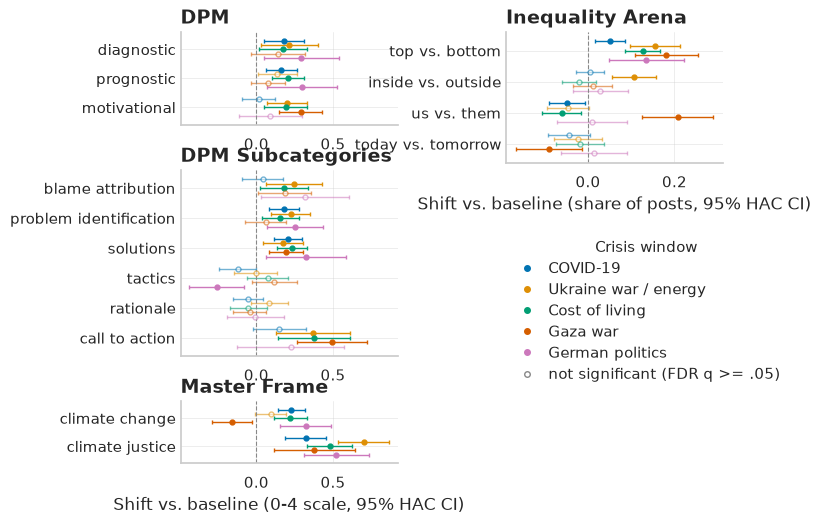

In [8]:
WINDOW_LABELS = {"covid": "COVID-19", "ukraine_energy": "Ukraine war / energy", "cost_of_living": "Cost of living",
                 "gaza": "Gaza war", "politics": "German politics"}
ARENA_LABELS = {"oben_unten": "top vs. bottom", "innen_aussen": "inside vs. outside",
                "wir_sie": "us vs. them", "heute_morgen": "today vs. tomorrow"}


def outcome_label(outcome):
    concept = outcome.replace("_present", "")
    return ARENA_LABELS.get(concept, concept.replace("_", " "))


def plot_window_shifts(shifts, filename):
    """Forest plot of every window shift, sized for one text-width figure: the three intensity
    axes (DPM, subcategories, master frame) stacked on the left on a shared 0-4 x scale, arena
    presence (share of posts) and the legend on the right."""
    window_colors = dict(zip(CRISIS_WINDOWS_ONLY, plot_style.PALETTE_LINES[:len(CRISIS_WINDOWS_ONLY)]))
    offsets = np.linspace(-0.3, 0.3, len(CRISIS_WINDOWS_ONLY))
    intensity_axes = ["DPM", "DPM Subcategories", "Master Frame"]
    presence_axis = "Inequality Arena"
    figsize = (plot_style.FIGSIZE_WIDE[0], 5.6)

    def draw_panel(ax, axis):
        outcomes = OUTCOMES[axis]
        for y, outcome in enumerate(outcomes):
            for window, offset in zip(CRISIS_WINDOWS_ONLY, offsets):
                row = shifts[(shifts["outcome"] == outcome) & (shifts["window"] == window)].iloc[0]
                color = window_colors[window]
                ax.errorbar(row["shift"], y + offset,
                            xerr=[[row["shift"] - row["ci_low"]], [row["ci_high"] - row["shift"]]],
                            fmt="o", color=color, markerfacecolor=color if row["significant"] else "white",
                            alpha=1.0 if row["significant"] else 0.55, capsize=1.5, markersize=3.5, linewidth=1)
        ax.axvline(0, color="#888", linewidth=0.8, linestyle="--")
        ax.set_yticks(range(len(outcomes)))
        ax.set_yticklabels([outcome_label(o) for o in outcomes])
        ax.set_ylim(len(outcomes) - 0.4, -0.6)
        ax.set_title(axis, loc="left", fontweight="bold")  # units live in the x-labels
        ax.tick_params(axis="y", length=0)

    with plot_style.scaled_fonts(figsize):
        fig = plt.figure(figsize=figsize)
        outer = fig.add_gridspec(1, 2, wspace=0.5)
        rows_left = [len(OUTCOMES[a]) for a in intensity_axes]
        rows_right = len(OUTCOMES[presence_axis])
        # left: one panel per intensity axis, rows proportional to concepts; right: the arena
        # panel at the same row height, then the legend in the remaining space
        left = outer[0].subgridspec(len(intensity_axes), 1, height_ratios=rows_left, hspace=0.4)
        right = outer[1].subgridspec(2, 1, height_ratios=[rows_right, sum(rows_left) - rows_right], hspace=0.4)

        left_panels = [fig.add_subplot(left[i]) for i in range(len(intensity_axes))]
        for ax, axis in zip(left_panels, intensity_axes):
            draw_panel(ax, axis)
        lo = min(ax.get_xlim()[0] for ax in left_panels)
        hi = max(ax.get_xlim()[1] for ax in left_panels)
        for ax in left_panels:
            ax.set_xlim(lo, hi)
        left_panels[-1].set_xlabel(f"Shift vs. {REFERENCE_WINDOW} (0-4 scale, 95% HAC CI)")

        arena_ax = fig.add_subplot(right[0])
        draw_panel(arena_ax, presence_axis)
        arena_ax.set_xlabel(f"Shift vs. {REFERENCE_WINDOW} (share of posts, 95% HAC CI)")

        legend_ax = fig.add_subplot(right[1])
        legend_ax.axis("off")
        handles = [Line2D([0], [0], marker="o", color=c, linestyle="", markersize=4, label=WINDOW_LABELS[w])
                   for w, c in window_colors.items()]
        handles.append(Line2D([0], [0], marker="o", color="#888", markerfacecolor="white", linestyle="",
                              markersize=4, label="not significant (FDR q >= .05)"))
        legend_ax.legend(handles=handles, title="Crisis window", loc="upper left", frameon=False,
                         borderaxespad=0, handletextpad=0.4, labelspacing=0.4)
        plot_style.savefig(fig, filename)
        plt.show()


plot_window_shifts(shifts, "FFF/crisis_window_shifts")

## H1: Extension into the Matching Arena

For each arena with a predicted crisis, the contrast *shift in the matched window minus the
mean shift across the other crisis windows*, tested on the fitted model's HAC covariance. H1
is supported for an arena if the contrast is positive and significant. The falsification is
built in: if `oben_unten` rose as much in the Ukraine window as in the cost-of-living window,
"extension follows the crisis" is not what is going on. The politics window has no arena
prediction (a domestic government crisis is not one of Mau et al.'s inequality arenas), so it
only enters as one of the "other" windows.

In [9]:
H1_MATCHES = {"innen_aussen": "ukraine_energy", "oben_unten": "cost_of_living", "wir_sie": "gaza"}


def matched_vs_others(fit, matched):
    others = [w for w in CRISIS_WINDOWS_ONLY if w != matched]
    contrast = pd.Series(0.0, index=fit.params.index)
    contrast[window_term(matched)] = 1.0
    contrast[[window_term(w) for w in others]] = -1.0 / len(others)
    test = fit.t_test(contrast.values)
    return scalar(test.effect), scalar(test.pvalue)


h1_rows = []
for arena, matched in H1_MATCHES.items():
    fit = fits[f"{arena}_present"]
    difference, pvalue = matched_vs_others(fit, matched)
    h1_rows.append({
        "arena": arena, "matched_window": matched,
        "shift_matched": fit.params[window_term(matched)],
        "mean_shift_others": fit.params[window_term(matched)] - difference,
        "difference": difference, "pvalue": pvalue,
        "supported": difference > 0 and pvalue < 0.05,
    })
h1 = pd.DataFrame(h1_rows).set_index("arena")
h1.round(3)

,matched_window,shift_matched,mean_shift_others,difference,pvalue,supported
arena,,,,,,
innen_aussen,ukraine_energy,0.107,0.006,0.101,0.000,True
oben_unten,cost_of_living,0.126,0.130,-0.004,0.863,False
wir_sie,gaza,0.207,-0.036,0.243,0.000,True


## H2: Master-Frame Shift Toward Justice

Outcome: the per-post gap `climate_justice - climate_change`. A positive window shift means the
justice frame gained on the climate-change frame relative to baseline.

In [10]:
h2 = window_shifts(fit_window_model("justice_gap"), "justice_gap").set_index("window")
h2["supported (gap widens)"] = (h2["shift"] > 0) & (h2["pvalue"] < 0.05)
h2.round(3)

,outcome,shift,ci_low,ci_high,pvalue,supported (gap widens)
window,,,,,,
covid,justice_gap,0.094,-0.038,0.225,0.162,False
ukraine_energy,justice_gap,0.607,0.453,0.760,0.000,True
cost_of_living,justice_gap,0.257,0.096,0.418,0.002,True
gaza,justice_gap,0.539,0.310,0.768,0.000,True
politics,justice_gap,0.200,-0.030,0.430,0.088,False


## H3: Amplification of Mobilization

Outcomes: `motivational` and `diagnostic` as shares of a post's DPM total (posts with all three
DPM scores at 0 drop out). H3 predicts positive shifts for the motivational share and negative
for the diagnostic share, largest in the politics (election) window.

In [11]:
h3 = pd.concat([window_shifts(fit_window_model(o), o) for o in ["motivational_share", "diagnostic_share"]])
h3 = h3.pivot(index="window", columns="outcome", values=["shift", "ci_low", "ci_high", "pvalue"]).loc[CRISIS_WINDOWS_ONLY]
h3.round(3)

shift                              ci_low  \
outcome        diagnostic_share motivational_share diagnostic_share   
window                                                                
covid                     0.012             -0.026           -0.006   
ukraine_energy            0.004             -0.009           -0.021   
cost_of_living            0.001             -0.023           -0.025   
gaza                      0.005             -0.005           -0.028   
politics                  0.030             -0.048           -0.009   

                                           ci_high                     \
outcome        motivational_share diagnostic_share motivational_share   
window                                                                  
covid                      -0.048            0.030             -0.005   
ukraine_energy             -0.038            0.029              0.020   
cost_of_living             -0.050            0.027              0.005   
gaza                       -0.038            0.038              0.028   
politics                   -0.087            0.069             -0.008   

                         pvalue                     
outcome        diagnostic_share motivational_share  
window                                              
covid                     0.204              0.016  
ukraine_energy            0.774              0.540  
cost_of_living            0.928              0.108  
gaza                      0.787              0.753  
politics                  0.129              0.018

## H4: Mobilization Peaks Before Participation Events

`pre_event` = the post falls in the 14 days before a highlighted key event (global strikes,
EU and Bundestag elections, `src/key_events.py`). `late_period` = Ukraine window onward. The
model has no window dummies (they would be collinear with `late_period`); it keeps the two
controls. H4 predicts `pre_event > 0` (mobilization framing rises ahead of events) and
`pre_event:late_period < 0` (the pre-event peak weakens over time).

In [12]:
event_dates = sorted(pd.Timestamp(e.date, tz="UTC") for e in KEY_EVENTS if e.highlight)


def days_to_next_event(ts):
    upcoming = [d for d in event_dates if d >= ts]
    return (upcoming[0] - ts).days if upcoming else np.nan


posts["days_to_event"] = posts["creation_time"].apply(days_to_next_event)
posts["pre_event"] = (posts["days_to_event"] <= 14).astype(int)
posts["late_period"] = posts["window"].isin(["ukraine_energy", "cost_of_living", "gaza", "politics"]).astype(int)
print(f"{len(event_dates)} highlighted events; {posts['pre_event'].mean():.0%} of posts fall in the 14 days before one")

h4_fit = fit_hac("motivational_share ~ pre_event * late_period + log_words + C(account)",
                 posts.dropna(subset=["motivational_share"]))
ci = h4_fit.conf_int()
h4 = pd.DataFrame({"coef": h4_fit.params, "ci_low": ci[0], "ci_high": ci[1], "pvalue": h4_fit.pvalues}).loc[["pre_event", "late_period", "pre_event:late_period"]]
h4.round(3)

20 highlighted events; 22% of posts fall in the 14 days before one


,coef,ci_low,ci_high,pvalue
pre_event,0.072,0.050,0.094,0.000
late_period,-0.008,-0.027,0.011,0.416
pre_event:late_period,-0.006,-0.040,0.028,0.742


## Verdict

One line per hypothesis (`*` = p < .05, uncorrected -- four pre-stated tests). Shifts are vs.
baseline, controlling for caption length and account.

In [13]:
def fmt(shift, p):
    return f"{shift:+.2f}{'*' if p < .05 else ''}"


verdict = pd.DataFrame([
    {"hypothesis": "H1 extension into matched arena",
     "result": f"{int(h1['supported'].sum())}/3 arenas: " + ", ".join(f"{a} {'yes' if s else 'no'}" for a, s in h1["supported"].items())},
    {"hypothesis": "H2 justice gap widens",
     "result": ", ".join(f"{w} {fmt(h2.loc[w, 'shift'], h2.loc[w, 'pvalue'])}" for w in CRISIS_WINDOWS_ONLY)},
    {"hypothesis": "H3 motivational share rises",
     "result": ", ".join(f"{w} {fmt(h3.loc[w, ('shift', 'motivational_share')], h3.loc[w, ('pvalue', 'motivational_share')])}" for w in CRISIS_WINDOWS_ONLY)},
    {"hypothesis": "H4 pre-event peak (x late period)",
     "result": f"pre_event {fmt(h4.loc['pre_event', 'coef'], h4.loc['pre_event', 'pvalue'])}, "
               f"x late {fmt(h4.loc['pre_event:late_period', 'coef'], h4.loc['pre_event:late_period', 'pvalue'])}"},
]).set_index("hypothesis")

with pd.option_context("display.max_colwidth", 200):
    display(verdict)

,result
hypothesis,
H1 extension into matched arena,"2/3 arenas: innen_aussen yes, oben_unten no, wir_sie yes"
H2 justice gap widens,"covid +0.09, ukraine_energy +0.61*, cost_of_living +0.26*, gaza +0.54*, politics +0.20"
H3 motivational share rises,"covid -0.03*, ukraine_energy -0.01, cost_of_living -0.02, gaza -0.01, politics -0.05*"
H4 pre-event peak (x late period),"pre_event +0.07*, x late -0.01"


Interpretation notes for the write-up: a supported hypothesis here means the pattern holds
*net of caption length and account* and *relative to the founding-phase baseline* -- not that
the crisis caused it. Rejected hypotheses are findings too: "frame extension into the arenas
without amplification of mobilization" is a substantive result, if that is what the tables
show.

## Save Results

In [14]:
output_path = Path("../data/processed/crisis_window_regression_results.csv")
shifts.to_csv(output_path, index=False)
print(f"saved {len(shifts)} window shifts to {output_path}")

saved 75 window shifts to ../data/processed/crisis_window_regression_results.csv
